# EnMAP Vendable Pipeline Walkthrough

This notebook walks through every stage of the vendable dataset generation pipeline for an **EnMAP L2A** hyperspectral scene. Each stage is visualized so you can see exactly what happens to the data at every step.

## Pipeline Stages

```
Raw EnMAP Scene (224 bands, int16 DN)
    |
[0] Raw data inspection
    |
[1] DN -> Surface Reflectance conversion (gain=0.0001)
    |
[2] Nodata + Pixel mask -> initial validity cube
    |
[3] Band filtering (bad bands, atmospheric, edge trim, coverage prune)
    |     224 bands -> ~188 bands
    |
[4] Quality mask invalidation (cloud, shadow, haze)
    |
[5] Spatial masking (>40% invalid voxels -> full pixel invalidation)
    |
[6] Spectral interpolation (PCHIP/linear gap-fill for partial pixels)
    |     Result: every pixel is fully valid or fully invalid
    |
[7] Spectral resampling to common 10nm grid (165 bands)
    |     Consistent across PRISMA and EnMAP
    |
[Final] Vendable dataset ready for patching/training
```

In [1]:
import os
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize

PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parents[0])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

SCENE_PATH = os.path.join(
    PROJECT_ROOT,
    "tests/test_payloads/ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z"
)
print(f"Scene: {os.path.basename(SCENE_PATH)}")
print(f"Files in scene folder:")
for f in sorted(os.listdir(SCENE_PATH)):
    size_mb = os.path.getsize(os.path.join(SCENE_PATH, f)) / 1024 / 1024
    print(f"  {f}: {size_mb:.1f} MB")

Scene: ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z
Files in scene folder:
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-HISTORY.XML: 1.8 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-METADATA.XML: 4.2 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_PIXELMASK.TIF: 4.7 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_QUALITY_CIRRUS.TIF: 0.1 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_QUALITY_CLASSES.TIF: 0.0 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_QUALITY_CLOUD.TIF: 0.0 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_QUALITY_CLOUDSHADOW.TIF: 0.0 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_20260305T173243Z-QL_QUALITY_HAZE.TIF: 0.0 MB
  ENMAP01-____L2A-DT0000059367_20240128T063655Z_018_V010506_

## Stage 0: Raw Data Inspection

Before any processing, let's look at what arrives from the satellite. The EnMAP L2A product is a folder containing:
- **SPECTRAL_IMAGE.TIF** — 224-band hyperspectral cube (int16 DN values)
- **QL_PIXELMASK.TIF** — per-band pixel validity (224 bands, 0=valid, 1=flagged)
- **QL_QUALITY_*.TIF** — quality masks (cloud, cirrus, haze, shadow, snow)
- **METADATA.XML** — band characterisation, detector boundaries, quality flags

We'll use the `EnmapHelper` to read the raw data directly, before any transformations.

In [2]:
from app.models.file_processing.sources import FileSourceConfig
from app.utils.files.enmap_helper import EnmapHelper
from app.templates.template_mappings import TEMPLATE_MAPPINGS, TemplateIdentifier
from app.models.hyperspectral_concepts.file_components import EnmapFileComponents

# Initialize helper to read raw data
helper = EnmapHelper(
    file_source_config=FileSourceConfig(source_path=SCENE_PATH),
    template=TEMPLATE_MAPPINGS.get(TemplateIdentifier.ENMAP_HYPERSPECTRAL),
)
metadata = helper.file_metadata

# Read raw spectral cube
raw_cube = helper.extract_specific_bands(bands=[], mode="all")
print(f"Raw spectral cube: shape={raw_cube.shape}, dtype={raw_cube.dtype}")
print(f"  Value range: [{raw_cube.min()}, {raw_cube.max()}]")
print(f"  Background value: {metadata.spatial_info.background_value}")

# Band characterisation summary
band_chars = metadata.band_characterisation
wavelengths = [bc.wavelength_center for bc in band_chars]
print(f"\nBand characterisation: {len(band_chars)} bands")
print(f"  Wavelength range: {min(wavelengths):.1f} - {max(wavelengths):.1f} nm")
print(f"  VNIR bands: {metadata.detector_boundary.num_vnir_bands}")
print(f"  SWIR bands: {metadata.detector_boundary.num_swir_bands}")

Raw spectral cube: shape=(224, 1179, 1320), dtype=int16
  Value range: [-32768, 6791]
  Background value: -32768

Band characterisation: 224 bands
  Wavelength range: 418.4 - 2445.3 nm
  VNIR bands: 91
  SWIR bands: 133


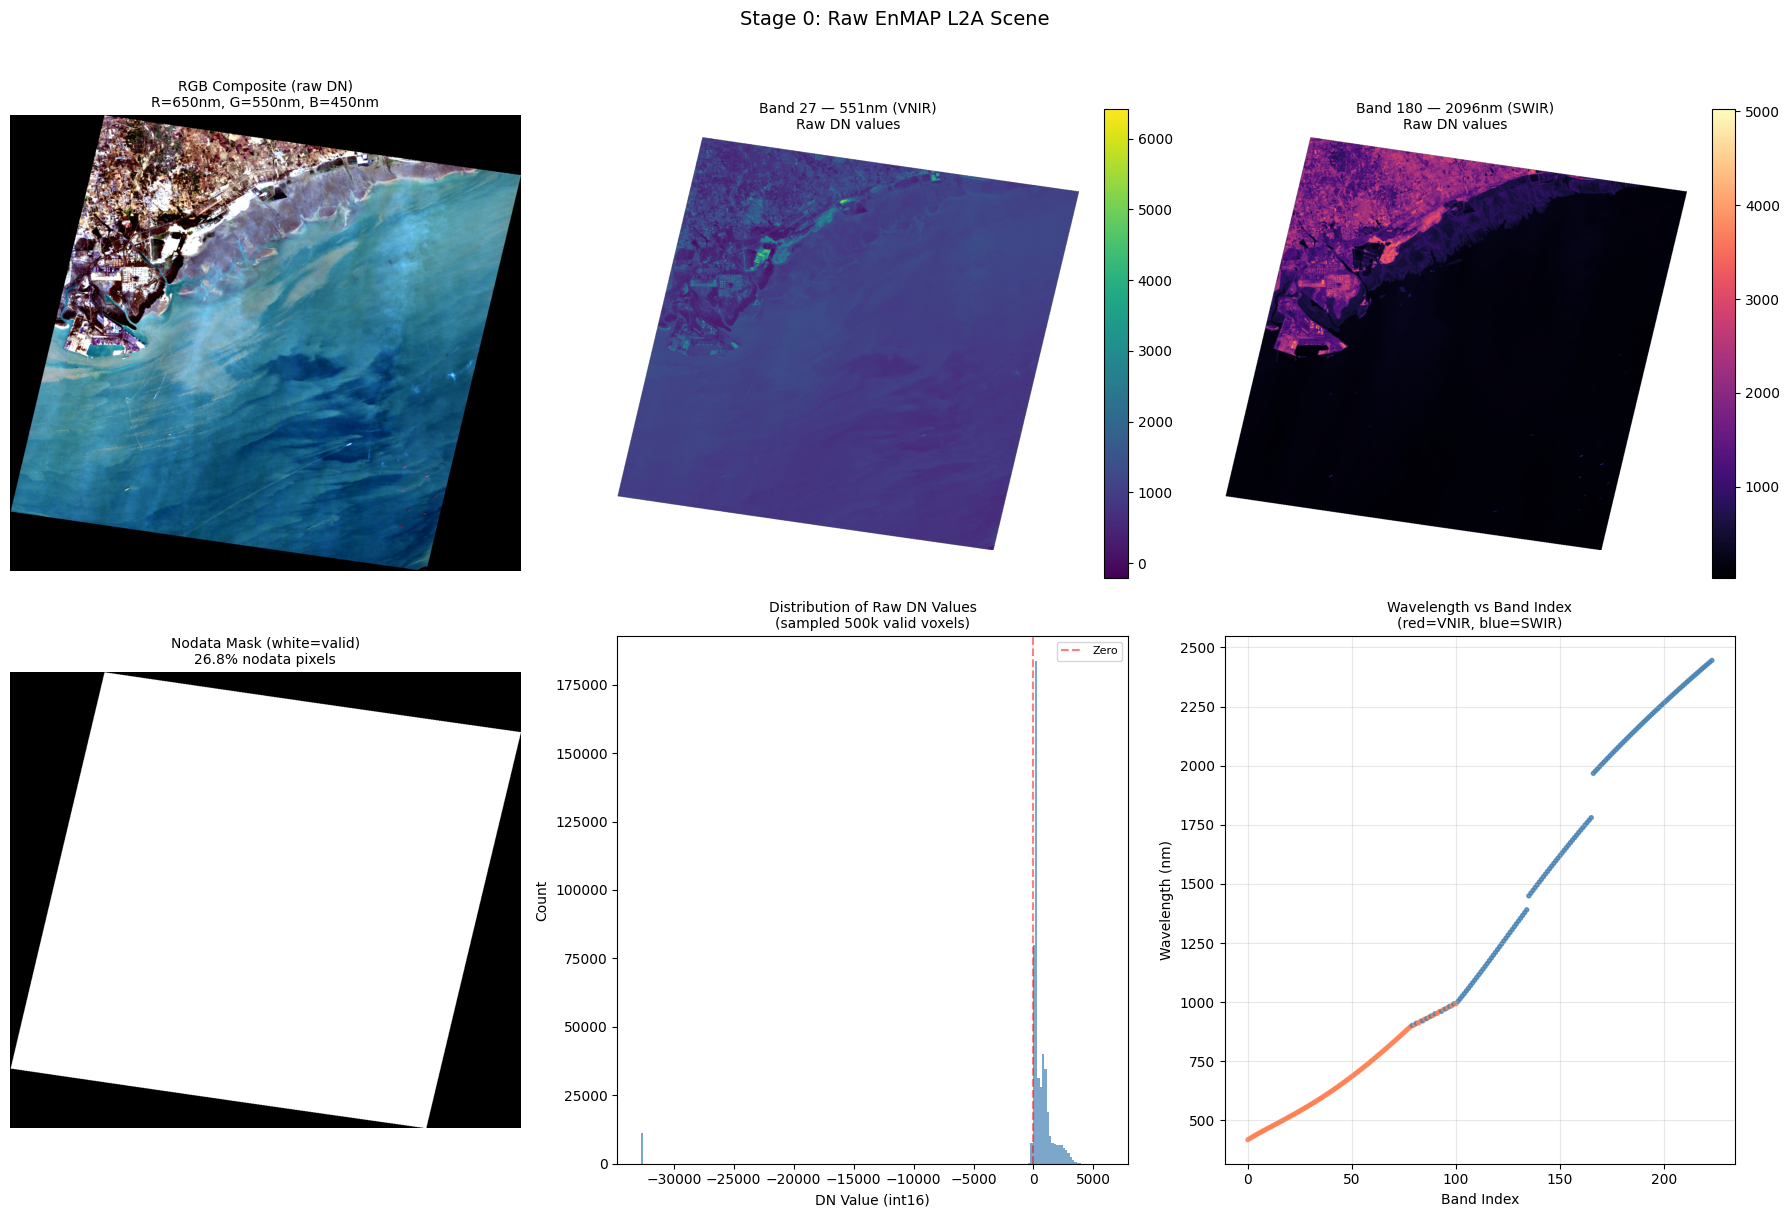

In [3]:
# Visualize the raw cube: RGB composite + single bands + spectral profile

def make_rgb_from_cube(cube, wavelengths, r_nm=650, g_nm=550, b_nm=450, validity=None):
    """Create RGB composite from nearest bands. cube is (C, H, W)."""
    wl = np.array(wavelengths)
    r_idx = np.argmin(np.abs(wl - r_nm))
    g_idx = np.argmin(np.abs(wl - g_nm))
    b_idx = np.argmin(np.abs(wl - b_nm))
    rgb = np.stack([cube[r_idx], cube[g_idx], cube[b_idx]], axis=-1).astype(np.float32)
    for ch in range(3):
        band = rgb[:, :, ch]
        if validity is not None:
            valid_vals = band[validity > 0]
        else:
            valid_vals = band[band != 0]
        if len(valid_vals) > 0:
            p2, p98 = np.percentile(valid_vals, [2, 98])
            rgb[:, :, ch] = np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1)
    if validity is not None:
        rgb[validity == 0] = 0
    return rgb

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: RGB + two single bands (raw DN)
nodata_mask = (raw_cube != metadata.spatial_info.background_value).any(axis=0).astype(np.uint8)
rgb_raw = make_rgb_from_cube(raw_cube.astype(np.float32), wavelengths, validity=nodata_mask)
axes[0, 0].imshow(rgb_raw)
axes[0, 0].set_title("RGB Composite (raw DN)\nR=650nm, G=550nm, B=450nm", fontsize=10)
axes[0, 0].axis("off")

# VNIR band (~550nm)
vnir_idx = np.argmin(np.abs(np.array(wavelengths) - 550))
band_vnir = np.ma.masked_where(nodata_mask == 0, raw_cube[vnir_idx].astype(np.float32))
im1 = axes[0, 1].imshow(band_vnir, cmap="viridis")
axes[0, 1].set_title(f"Band {vnir_idx} — {wavelengths[vnir_idx]:.0f}nm (VNIR)\nRaw DN values", fontsize=10)
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# SWIR band (~2100nm)
swir_idx = np.argmin(np.abs(np.array(wavelengths) - 2100))
band_swir = np.ma.masked_where(nodata_mask == 0, raw_cube[swir_idx].astype(np.float32))
im2 = axes[0, 2].imshow(band_swir, cmap="magma")
axes[0, 2].set_title(f"Band {swir_idx} — {wavelengths[swir_idx]:.0f}nm (SWIR)\nRaw DN values", fontsize=10)
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Row 2: Nodata mask, histogram of DN values, wavelength vs band index
axes[1, 0].imshow(nodata_mask, cmap="gray")
nodata_pct = (1 - nodata_mask.sum() / nodata_mask.size) * 100
axes[1, 0].set_title(f"Nodata Mask (white=valid)\n{nodata_pct:.1f}% nodata pixels", fontsize=10)
axes[1, 0].axis("off")

# DN histogram (sample from valid pixels)
valid_dns = raw_cube[:, nodata_mask == 1].ravel()
sample = np.random.default_rng(42).choice(valid_dns, min(500000, len(valid_dns)), replace=False)
axes[1, 1].hist(sample, bins=200, color="steelblue", alpha=0.7, edgecolor="none")
axes[1, 1].set_xlabel("DN Value (int16)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Distribution of Raw DN Values\n(sampled 500k valid voxels)", fontsize=10)
axes[1, 1].axvline(0, color="red", linestyle="--", alpha=0.5, label="Zero")
axes[1, 1].legend(fontsize=8)

# Wavelength vs band index with VNIR/SWIR coloring
vnir_channels = set(metadata.detector_boundary.vnir_expected_channels)
colors = ["coral" if bc.band_number in vnir_channels else "steelblue" for bc in band_chars]
axes[1, 2].scatter(range(len(wavelengths)), wavelengths, c=colors, s=8, alpha=0.8)
axes[1, 2].set_xlabel("Band Index")
axes[1, 2].set_ylabel("Wavelength (nm)")
axes[1, 2].set_title("Wavelength vs Band Index\n(red=VNIR, blue=SWIR)", fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle("Stage 0: Raw EnMAP L2A Scene", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Stage 1: DN to Surface Reflectance

EnMAP L2A provides atmospherically corrected data as int16 digital numbers. The conversion to physical surface reflectance is simple and uniform across all 224 bands:

```
Surface Reflectance = DN * 0.0001 + 0.0
```

This is a linear scaling — the gain (0.0001) is fixed for all bands in L2A products. Nodata pixels (DN = -32768) are set to 0.0 in the reflectance cube.

After conversion, reflectance values typically range from 0.0 to ~0.5 for most land surfaces, with occasional small negative values from atmospheric correction artifacts.

Surface reflectance cube: shape=(224, 1179, 1320), dtype=float32
Valid pixel reflectance range: [-0.0692, 0.6791]
Mean reflectance: 0.0594


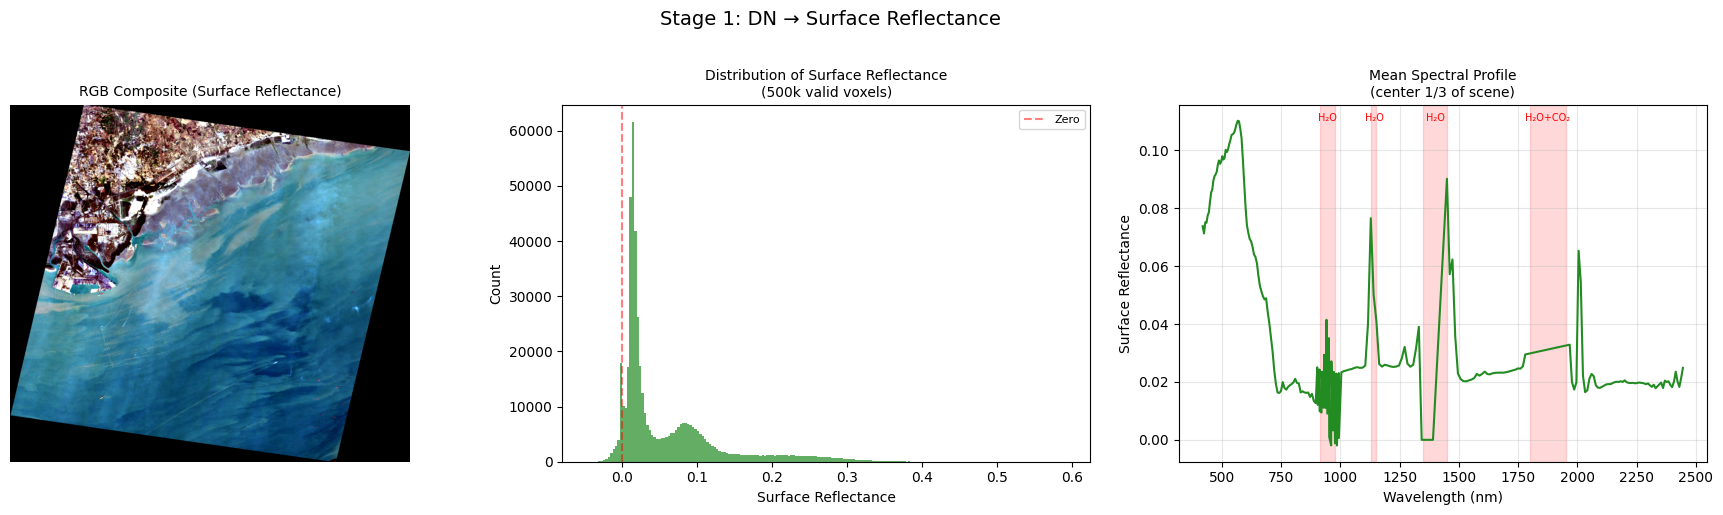

In [4]:
from app.utils.data_transformations.enmap_l2a_dn_to_surface_reflectance_transformer import (
    EnmapL2aDnToSurfaceReflectanceTransformer,
)

transformer = EnmapL2aDnToSurfaceReflectanceTransformer()
sr_cube = transformer.transform(
    input_data=raw_cube,
    nodata_value=metadata.spatial_info.background_value,
)

print(f"Surface reflectance cube: shape={sr_cube.shape}, dtype={sr_cube.dtype}")
valid_sr = sr_cube[:, nodata_mask == 1]
print(f"Valid pixel reflectance range: [{valid_sr.min():.4f}, {valid_sr.max():.4f}]")
print(f"Mean reflectance: {valid_sr.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RGB from reflectance
rgb_sr = make_rgb_from_cube(sr_cube, wavelengths, validity=nodata_mask)
axes[0].imshow(rgb_sr)
axes[0].set_title("RGB Composite (Surface Reflectance)", fontsize=10)
axes[0].axis("off")

# Reflectance histogram
sample_sr = np.random.default_rng(42).choice(valid_sr.ravel(), 500000, replace=False)
axes[1].hist(sample_sr, bins=200, color="forestgreen", alpha=0.7, edgecolor="none")
axes[1].set_xlabel("Surface Reflectance")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Surface Reflectance\n(500k valid voxels)", fontsize=10)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5, label="Zero")
axes[1].legend(fontsize=8)

# Mean spectral profile of a valid pixel region (center crop)
H, W = sr_cube.shape[1], sr_cube.shape[2]
crop = sr_cube[:, H//3:2*H//3, W//3:2*W//3]
crop_valid = nodata_mask[H//3:2*H//3, W//3:2*W//3]
mean_spectrum = crop[:, crop_valid == 1].mean(axis=1)
axes[2].plot(wavelengths, mean_spectrum, color="forestgreen", lw=1.5)
axes[2].set_xlabel("Wavelength (nm)")
axes[2].set_ylabel("Surface Reflectance")
axes[2].set_title("Mean Spectral Profile\n(center 1/3 of scene)", fontsize=10)
axes[2].grid(True, alpha=0.3)
# Shade atmospheric absorption windows
for lo, hi, label in [(912, 978, "H₂O"), (1131, 1152, "H₂O"), (1350, 1450, "H₂O"), (1800, 1950, "H₂O+CO₂")]:
    axes[2].axvspan(lo, hi, alpha=0.15, color="red")
    axes[2].text((lo+hi)/2, axes[2].get_ylim()[1]*0.95, label, ha="center", fontsize=7, color="red")

plt.suptitle("Stage 1: DN → Surface Reflectance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Stage 2: Initial Validity — Nodata Mask + Pixel Mask

Two sources of pixel-level invalidity exist before any filtering:

1. **Nodata mask**: Pixels where the DN equals the background value (-32768) are nodata — the satellite didn't acquire data there (scene edges, orbital geometry). Convention: 1=valid, 0=nodata.

2. **Pixel mask** (`QL_PIXELMASK.TIF`): A 224-band mask where the sensor flags per-band pixel quality issues. EnMAP convention is inverted from ours: 0=valid, 1=flagged. We flip it so 1=valid, 0=invalid.

The **initial validity cube** is `nodata_mask * pixel_mask` — a pixel-band voxel must be both data-present AND sensor-approved to be valid.

Initial validity cube: (224, 1179, 1320)
Valid voxels: 245,764,588 / 348,606,720 (70.5%)

Pixel summary (across 224 bands):
  Fully valid (all 224 bands):  0 (0.0%)
  Fully invalid (0 bands):      417,632 (26.8%)
  Partially valid:              1,138,648 (73.2%)


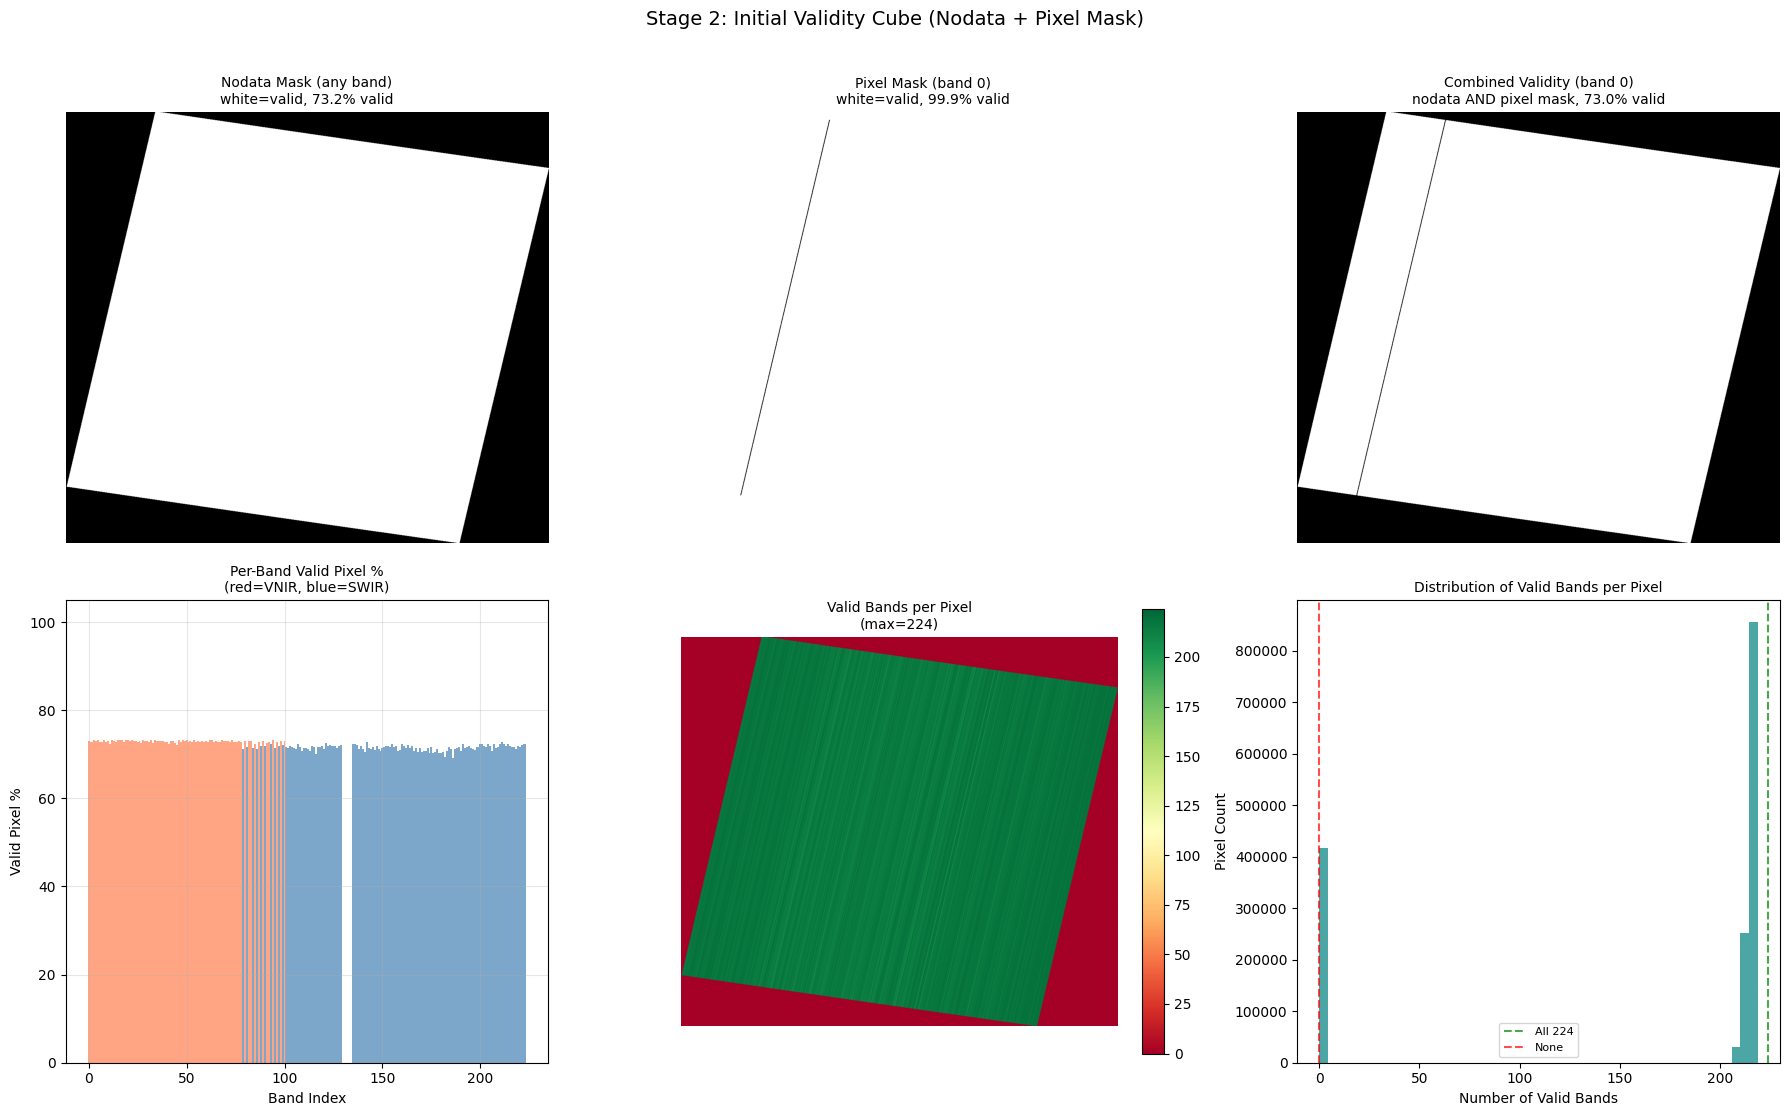

In [5]:
# Build validity components
nodata_cube = (raw_cube != metadata.spatial_info.background_value).astype(np.int8)
pixel_mask_raw = helper.extract_pixel_mask()
pixel_mask = (1 - pixel_mask_raw).astype(np.uint8)  # Flip convention: 1=valid
initial_validity = nodata_cube * pixel_mask.astype(np.int8)

C, H, W = initial_validity.shape
total_voxels = C * H * W
valid_voxels = initial_validity.sum()
print(f"Initial validity cube: {initial_validity.shape}")
print(f"Valid voxels: {valid_voxels:,} / {total_voxels:,} ({valid_voxels/total_voxels*100:.1f}%)")

# Per-band validity profile
band_validity_pct = [initial_validity[b].sum() / (H * W) * 100 for b in range(C)]

# Pixel-level summary
valid_per_pixel = initial_validity.sum(axis=0)
fully_valid = (valid_per_pixel == C).sum()
fully_invalid = (valid_per_pixel == 0).sum()
partial = ((valid_per_pixel > 0) & (valid_per_pixel < C)).sum()
print(f"\nPixel summary (across {C} bands):")
print(f"  Fully valid (all {C} bands):  {fully_valid:,} ({fully_valid/(H*W)*100:.1f}%)")
print(f"  Fully invalid (0 bands):      {fully_invalid:,} ({fully_invalid/(H*W)*100:.1f}%)")
print(f"  Partially valid:              {partial:,} ({partial/(H*W)*100:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Nodata spatial mask (any band)
axes[0, 0].imshow(nodata_mask, cmap="gray")
axes[0, 0].set_title(f"Nodata Mask (any band)\nwhite=valid, {nodata_mask.sum()/(H*W)*100:.1f}% valid", fontsize=10)
axes[0, 0].axis("off")

# Pixel mask - show band 0 as example
axes[0, 1].imshow(pixel_mask[0], cmap="gray")
pix_valid_b0 = pixel_mask[0].sum() / (H * W) * 100
axes[0, 1].set_title(f"Pixel Mask (band 0)\nwhite=valid, {pix_valid_b0:.1f}% valid", fontsize=10)
axes[0, 1].axis("off")

# Combined validity - band 0
axes[0, 2].imshow(initial_validity[0], cmap="gray")
comb_b0 = initial_validity[0].sum() / (H * W) * 100
axes[0, 2].set_title(f"Combined Validity (band 0)\nnodata AND pixel mask, {comb_b0:.1f}% valid", fontsize=10)
axes[0, 2].axis("off")

# Per-band validity bar chart
colors_band = ["coral" if bc.band_number in vnir_channels else "steelblue" for bc in band_chars]
axes[1, 0].bar(range(C), band_validity_pct, color=colors_band, width=1.0, alpha=0.7)
axes[1, 0].set_xlabel("Band Index")
axes[1, 0].set_ylabel("Valid Pixel %")
axes[1, 0].set_title("Per-Band Valid Pixel %\n(red=VNIR, blue=SWIR)", fontsize=10)
axes[1, 0].set_ylim([0, 105])
axes[1, 0].grid(True, alpha=0.3)

# Valid band count per pixel (spatial map)
im3 = axes[1, 1].imshow(valid_per_pixel, cmap="RdYlGn", vmin=0, vmax=C)
axes[1, 1].set_title(f"Valid Bands per Pixel\n(max={C})", fontsize=10)
axes[1, 1].axis("off")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)

# Histogram of valid bands per pixel
axes[1, 2].hist(valid_per_pixel.ravel(), bins=50, color="teal", alpha=0.7, edgecolor="none")
axes[1, 2].set_xlabel("Number of Valid Bands")
axes[1, 2].set_ylabel("Pixel Count")
axes[1, 2].set_title("Distribution of Valid Bands per Pixel", fontsize=10)
axes[1, 2].axvline(C, color="green", linestyle="--", alpha=0.7, label=f"All {C}")
axes[1, 2].axvline(0, color="red", linestyle="--", alpha=0.7, label="None")
axes[1, 2].legend(fontsize=8)

plt.suptitle("Stage 2: Initial Validity Cube (Nodata + Pixel Mask)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Stage 3: Band Filtering

Four filtering stages remove unreliable spectral bands:

1. **Bad band flags** — EnMAP has no per-band invalidity flags (all bands marked valid), so nothing is removed here.
2. **Wavelength exclusion** — Removes bands in atmospheric absorption windows where the atmosphere is opaque: (0-450nm), (912-978nm), (1131-1152nm), (1350-1450nm), (1800-1950nm).
3. **Edge trimming** — Removes the first/last 3 bands from each detector (VNIR, SWIR). Detector edges have lower SNR due to reduced sensitivity.
4. **Coverage pruning** — Removes bands where fewer than 20% of pixels are valid.

We'll build the vendable **without** the later stages (spatial masking, interpolation, resampling) first, then show the band filtering effect.

Band filtering summary:
  Total bands:             224
  Dropped by flags:        0
  Dropped by wavelength:   28
  Dropped by edge trim:    7
  Dropped by coverage:     1
  Surviving bands:         188


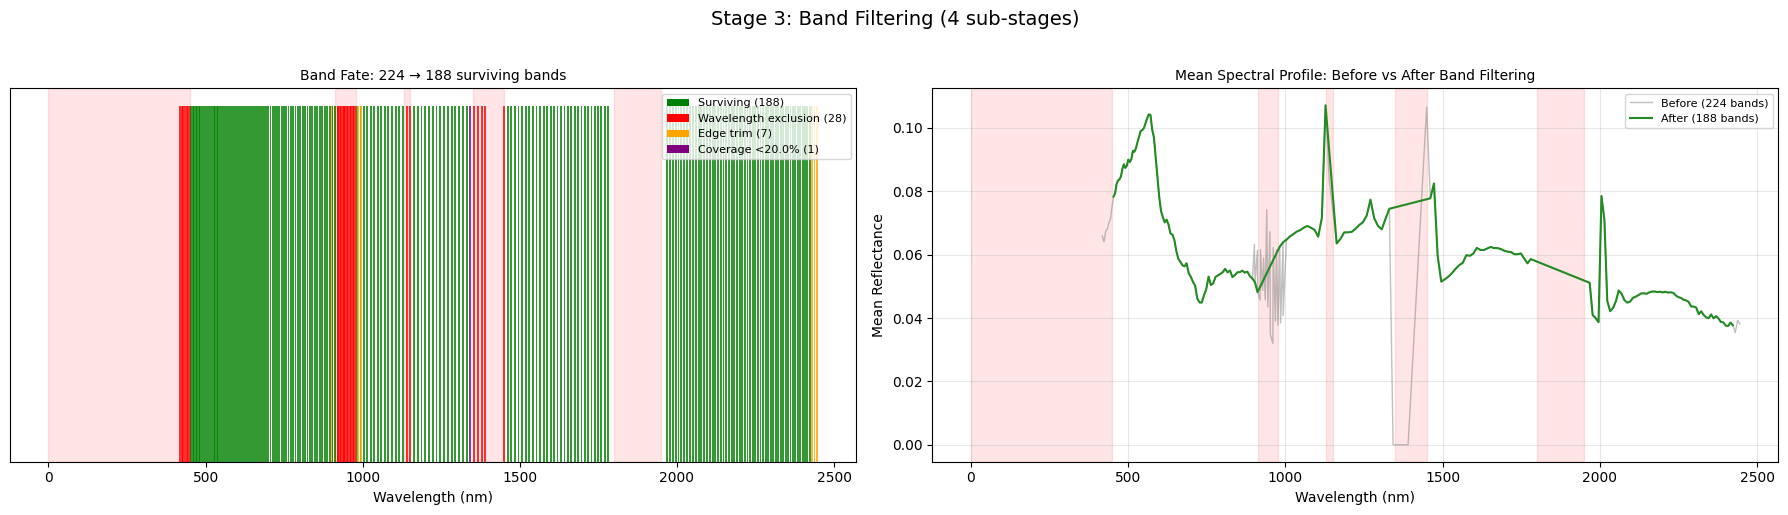

In [6]:
from app.utils.data_transformations.spectral_band_filter import SpectralBandFilter
from app.models.dataset.vendables import BandFilterConfig
from app.models.hyperspectral_concepts.spectral_family import SpectralFamily

# Use the band filter to see what gets removed
cfg = BandFilterConfig()

# Build band metadata (same as builder does)
spectral_family_order = []
band_cw_order = []
band_validity_flags = []
vnir_ch = set(metadata.detector_boundary.vnir_expected_channels)
for bc in band_chars:
    if bc.band_number in vnir_ch:
        spectral_family_order.append(SpectralFamily.VNIR)
    else:
        spectral_family_order.append(SpectralFamily.SWIR)
    band_cw_order.append(bc.wavelength_center)
    band_validity_flags.append(1)  # EnMAP: all bands valid

# Compute per-band validity scores from initial validity cube
band_scores = [float(initial_validity[b].sum() / (H * W) * 100) for b in range(C)]

band_filter = SpectralBandFilter(
    band_wavelengths=band_cw_order,
    band_validity_flags=band_validity_flags,
    exclusion_ranges=cfg.exclusion_ranges,
    spectral_families=spectral_family_order,
    edge_bands_to_trim=cfg.edge_bands_to_trim,
    band_level_validity_scores=band_scores,
    min_valid_pixel_pct=cfg.min_valid_pixel_pct,
)
good_idx = band_filter.get_good_band_indices()
summary = band_filter.summary()

print(f"Band filtering summary:")
print(f"  Total bands:             {summary['total_bands']}")
print(f"  Dropped by flags:        {summary['dropped_by_flags']['count']}")
print(f"  Dropped by wavelength:   {summary['dropped_by_wavelength']['count']}")
print(f"  Dropped by edge trim:    {summary['dropped_by_edge']['count']}")
print(f"  Dropped by coverage:     {summary['dropped_by_coverage']['count']}")
print(f"  Surviving bands:         {summary['surviving']}")

# Visualize: which bands survive?
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Band fate map
band_fate = np.zeros(C)  # 0 = dropped
for i in good_idx:
    band_fate[i] = 4  # surviving
for i in summary["dropped_by_flags"]["indices"]:
    band_fate[i] = 1
for i in summary["dropped_by_wavelength"]["indices"]:
    band_fate[i] = 1
for i in summary["dropped_by_edge"]["indices"]:
    band_fate[i] = 2
for i in summary["dropped_by_coverage"]["indices"]:
    band_fate[i] = 3

cmap_fate = plt.cm.colors.ListedColormap(["lightgray", "red", "orange", "purple", "green"])
wl_arr = np.array(band_cw_order)
for i in range(C):
    color = ["lightgray", "red", "orange", "purple", "green"][int(band_fate[i])]
    axes[0].bar(wl_arr[i], 1, width=6, color=color, alpha=0.8)

axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("")
axes[0].set_yticks([])
axes[0].set_title(f"Band Fate: 224 → {summary['surviving']} surviving bands", fontsize=10)
# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", label=f"Surviving ({summary['surviving']})"),
    Patch(facecolor="red", label=f"Wavelength exclusion ({summary['dropped_by_wavelength']['count']})"),
    Patch(facecolor="orange", label=f"Edge trim ({summary['dropped_by_edge']['count']})"),
    Patch(facecolor="purple", label=f"Coverage <{cfg.min_valid_pixel_pct}% ({summary['dropped_by_coverage']['count']})"),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc="upper right")

# Shaded exclusion zones
for lo, hi in cfg.exclusion_ranges:
    axes[0].axvspan(lo, hi, alpha=0.1, color="red")

# Before/after spectral profile comparison
surviving_wl = [band_cw_order[i] for i in good_idx]
mean_before = sr_cube[:, nodata_mask == 1].mean(axis=1)
mean_after = mean_before[good_idx]

axes[1].plot(band_cw_order, mean_before, color="gray", lw=1, alpha=0.5, label=f"Before ({C} bands)")
axes[1].plot(surviving_wl, mean_after, color="forestgreen", lw=1.5, label=f"After ({len(good_idx)} bands)")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Mean Reflectance")
axes[1].set_title("Mean Spectral Profile: Before vs After Band Filtering", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
for lo, hi in cfg.exclusion_ranges:
    axes[1].axvspan(lo, hi, alpha=0.1, color="red")

plt.suptitle("Stage 3: Band Filtering (4 sub-stages)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Stages 4–7: Full Pipeline via `vend_dataset()`

The remaining stages happen inside `vend_dataset()` when a `BandFilterConfig` is provided. We'll build the vendable with three different configs to see each stage's effect:

- **Config A**: Band filtering only (no spatial masking, no interpolation, no resampling)
- **Config B**: Band filtering + spatial masking + interpolation (no resampling)
- **Config C**: Full pipeline including resampling to common 165-band grid

This lets us isolate and visualize each stage's contribution.

In [7]:
from app.utils.dataset_builder.enmap_dataset_builder import EnmapDatasetBuilder
from app.models.dataset.vendables import DEFAULT_COMMON_WAVELENGTH_GRID

file_cfg = FileSourceConfig(source_path=SCENE_PATH)

# Build three vendables to isolate each stage
print("Building vendable A (band filtering only, no spatial/interp/resample)...")
# We'll use the full pipeline vendable and compare, but first the unfiltered baseline
builder_raw = EnmapDatasetBuilder(file_source_configuration=file_cfg)
ds_raw = builder_raw.vend_dataset()  # No filtering at all

print("Building vendable B (full pipeline, no resampling)...")
builder_b = EnmapDatasetBuilder(file_source_configuration=file_cfg)
ds_filtered = builder_b.vend_dataset(band_filter_config=BandFilterConfig())

print("Building vendable C (full pipeline + resampling to common grid)...")
builder_c = EnmapDatasetBuilder(file_source_configuration=file_cfg)
ds_resampled = builder_c.vend_dataset(band_filter_config=BandFilterConfig(
    common_wavelength_grid=DEFAULT_COMMON_WAVELENGTH_GRID
))

print(f"\nResults:")
print(f"  Raw (no filter):       {ds_raw.normalized_hyperspectral_cube.shape}")
print(f"  Filtered (no resamp):  {ds_filtered.normalized_hyperspectral_cube.shape}")
print(f"  Resampled (final):     {ds_resampled.normalized_hyperspectral_cube.shape}")

Building vendable A (band filtering only, no spatial/interp/resample)...
Building vendable B (full pipeline, no resampling)...
Building vendable C (full pipeline + resampling to common grid)...

Results:
  Raw (no filter):       (224, 1179, 1320)
  Filtered (no resamp):  (188, 1179, 1320)
  Resampled (final):     (165, 1179, 1320)


### Stage 4: Quality Mask Invalidation + Stage 5: Spatial Masking

**Quality mask invalidation** (EnMAP-specific): Pixels flagged by cloud, cloud shadow, or haze quality layers have their entire validity column zeroed — even if their spectral data looks structurally valid, the atmospheric contamination makes it unreliable.

**Spatial masking**: After quality mask invalidation, any pixel where more than 40% of bands are invalid gets its entire column zeroed. This converts the validity landscape from a mix of fully-valid, fully-invalid, and partially-valid into just three clean categories.

Let's compare the validity landscape before and after these stages.

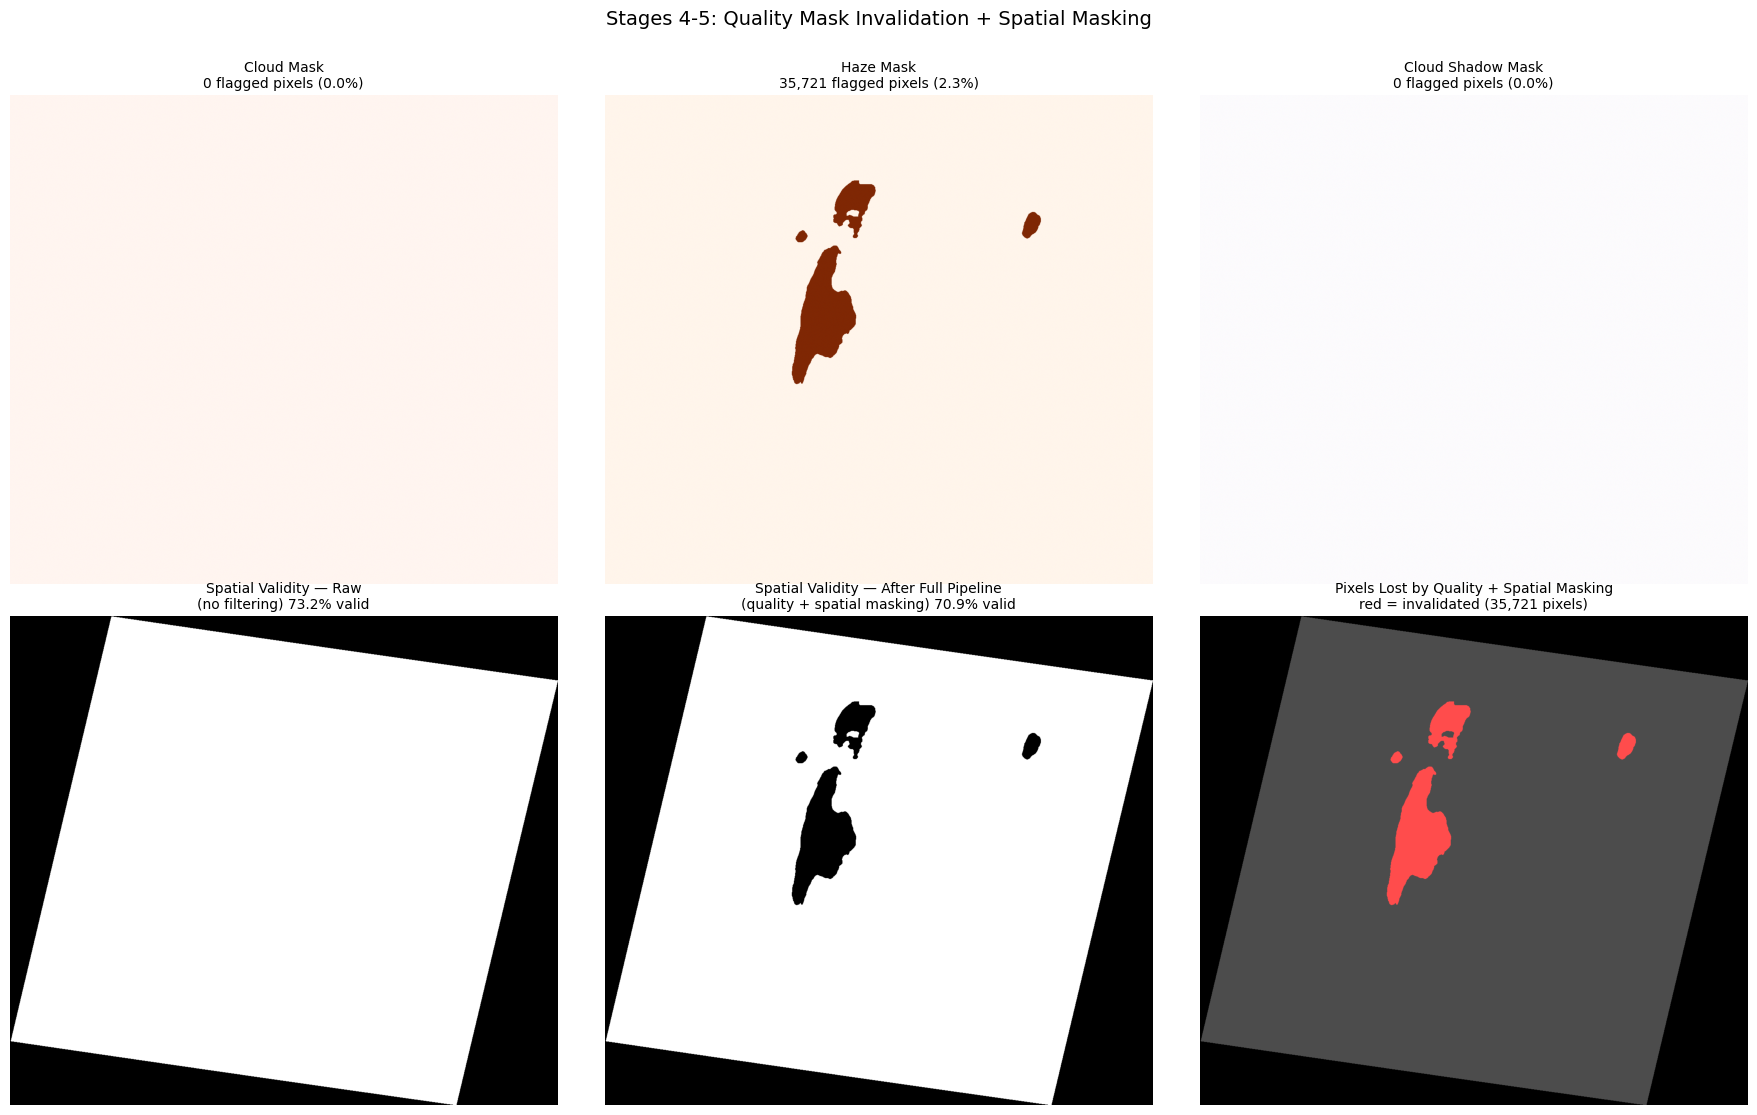

Pixels before quality/spatial masking: 1,138,648
Pixels after quality/spatial masking:  1,102,927
Pixels lost: 35,721 (3.1%)


In [8]:
# Compare quality masks and their effect
cloud_mask = helper.extract_quality_mask(EnmapFileComponents.QUALITY_CLOUD)
haze_mask = helper.extract_quality_mask(EnmapFileComponents.QUALITY_HAZE)
shadow_mask = helper.extract_quality_mask(EnmapFileComponents.QUALITY_CLOUDSHADOW)
cirrus_mask = helper.extract_quality_mask(EnmapFileComponents.QUALITY_CIRRUS)
snow_mask = helper.extract_quality_mask(EnmapFileComponents.QUALITY_SNOW)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 1: Quality masks
masks = [
    ("Cloud", cloud_mask, "Reds"),
    ("Haze", haze_mask, "Oranges"),
    ("Cloud Shadow", shadow_mask, "Purples"),
]
for idx, (name, mask, cmap) in enumerate(masks):
    flagged = (mask > 0).sum()
    axes[0, idx].imshow(mask, cmap=cmap)
    axes[0, idx].set_title(f"{name} Mask\n{flagged:,} flagged pixels ({flagged/(H*W)*100:.1f}%)", fontsize=10)
    axes[0, idx].axis("off")

# Row 2: Before vs After spatial validity comparison
v_raw = ds_raw.validity_cube
v_filtered = ds_filtered.validity_cube

# Raw: valid bands per pixel
raw_valid_per_px = v_raw.sum(axis=0)
C_raw = v_raw.shape[0]
raw_spatial = (raw_valid_per_px > 0).astype(np.uint8)

# Filtered: validity is binary per pixel after pipeline
C_filt = v_filtered.shape[0]
filt_spatial = (v_filtered.sum(axis=0) > 0).astype(np.uint8)

axes[1, 0].imshow(raw_spatial, cmap="gray")
raw_valid_pct = raw_spatial.sum() / raw_spatial.size * 100
axes[1, 0].set_title(f"Spatial Validity — Raw\n(no filtering) {raw_valid_pct:.1f}% valid", fontsize=10)
axes[1, 0].axis("off")

axes[1, 1].imshow(filt_spatial, cmap="gray")
filt_valid_pct = filt_spatial.sum() / filt_spatial.size * 100
axes[1, 1].set_title(f"Spatial Validity — After Full Pipeline\n(quality + spatial masking) {filt_valid_pct:.1f}% valid", fontsize=10)
axes[1, 1].axis("off")

# Difference: pixels lost
diff = raw_spatial.astype(int) - filt_spatial.astype(int)
lost_pixels = (diff > 0).sum()
display = np.zeros((*raw_spatial.shape, 3))
display[filt_spatial == 1] = [0.3, 0.3, 0.3]  # survived = gray
display[diff > 0] = [1, 0.3, 0.3]              # lost = red
display[(raw_spatial == 0) & (filt_spatial == 0)] = [0, 0, 0]  # always invalid = black
axes[1, 2].imshow(display)
axes[1, 2].set_title(f"Pixels Lost by Quality + Spatial Masking\nred = invalidated ({lost_pixels:,} pixels)", fontsize=10)
axes[1, 2].axis("off")

plt.suptitle("Stages 4-5: Quality Mask Invalidation + Spatial Masking", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print summary
print(f"Pixels before quality/spatial masking: {int(raw_spatial.sum()):,}")
print(f"Pixels after quality/spatial masking:  {int(filt_spatial.sum()):,}")
print(f"Pixels lost: {lost_pixels:,} ({lost_pixels/raw_spatial.sum()*100:.1f}%)")

### Stage 6: Spectral Interpolation

After spatial masking, the validity cube has three pixel categories:
- **Fully valid**: all bands valid (no action needed)
- **Fully invalid**: all bands zeroed (no data to interpolate from)
- **Partially valid**: some bands valid, some gaps

For partially-valid pixels, the spectral interpolation fills the gaps using the valid bands as anchors:
- **Large pattern groups** (>=5000 pixels with the same gap pattern): vectorized PCHIP interpolation
- **Small groups / singletons**: `np.interp` (C-accelerated linear interpolation)
- **Edge bands**: constant extrapolation (clamped to nearest valid value)

After interpolation, **every pixel is either fully valid or fully invalid** — no partial validity remains. This is the key invariant that makes downstream processing clean.

After full pipeline (188 bands):
  Fully valid:   1,102,927 pixels (70.9%)
  Fully invalid: 453,353 pixels (29.1%)
  Partial:       0 pixels (should be 0)


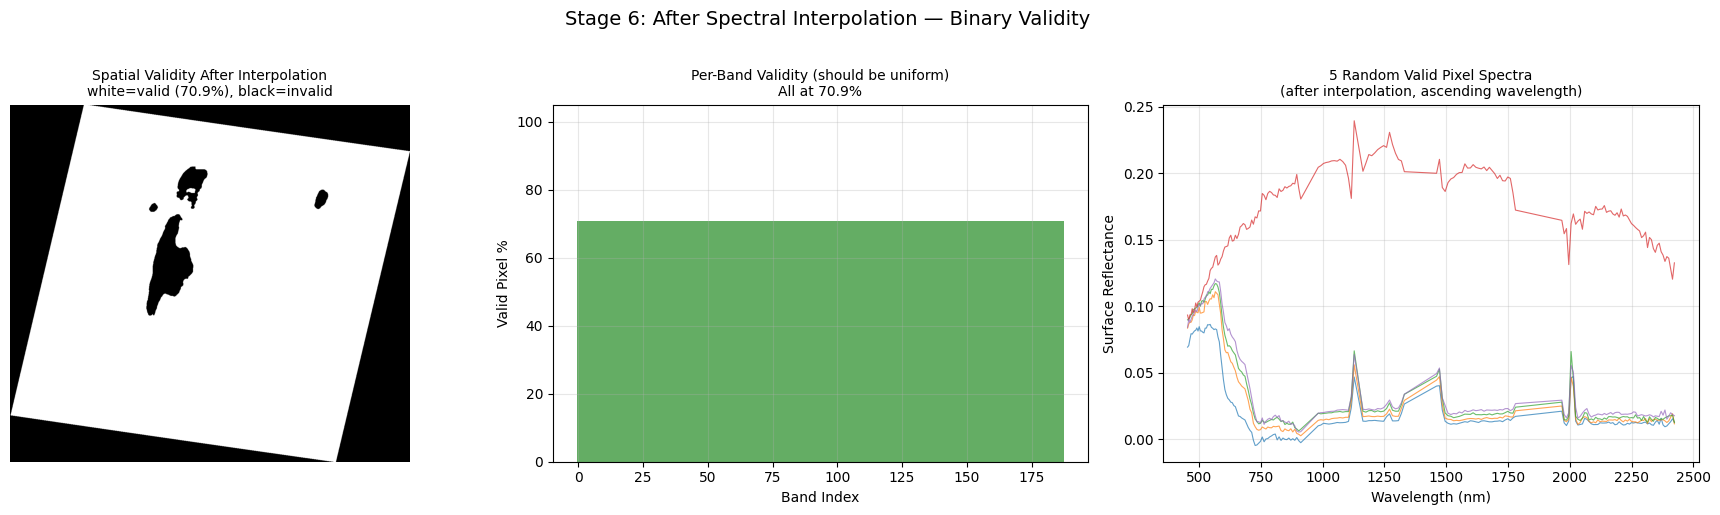

In [9]:
# After the full pipeline (ds_filtered), validity is binary per pixel.
# Let's verify and visualize the result.

v = ds_filtered.validity_cube
C_f = v.shape[0]
valid_per_px = v.sum(axis=0)

fully_valid = int((valid_per_px == C_f).sum())
fully_invalid = int((valid_per_px == 0).sum())
partial = int(((valid_per_px > 0) & (valid_per_px < C_f)).sum())
total = v.shape[1] * v.shape[2]

print(f"After full pipeline ({C_f} bands):")
print(f"  Fully valid:   {fully_valid:,} pixels ({fully_valid/total*100:.1f}%)")
print(f"  Fully invalid: {fully_invalid:,} pixels ({fully_invalid/total*100:.1f}%)")
print(f"  Partial:       {partial:,} pixels (should be 0)")

# Per-band validity — should be uniform since validity is pixel-level
band_scores = ds_filtered.band_level_validity_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Spatial validity map (clean binary)
spatial_v = (valid_per_px > 0).astype(np.uint8)
axes[0].imshow(spatial_v, cmap="gray")
axes[0].set_title(f"Spatial Validity After Interpolation\nwhite=valid ({fully_valid/total*100:.1f}%), black=invalid", fontsize=10)
axes[0].axis("off")

# Per-band validity bar chart — should be flat
filt_wl = ds_filtered.band_cw_order
axes[1].bar(range(C_f), band_scores, color="forestgreen", width=1.0, alpha=0.7)
axes[1].set_xlabel("Band Index")
axes[1].set_ylabel("Valid Pixel %")
axes[1].set_title(f"Per-Band Validity (should be uniform)\nAll at {band_scores[0]:.1f}%", fontsize=10)
axes[1].set_ylim([0, 105])
axes[1].grid(True, alpha=0.3)

# Sample spectral profiles: pick 5 random valid pixels and plot their spectra
rng = np.random.default_rng(42)
valid_pixels = np.argwhere(spatial_v == 1)
sample_px = valid_pixels[rng.choice(len(valid_pixels), 5, replace=False)]
cube_f = ds_filtered.normalized_hyperspectral_cube

filt_wl_sorted = sorted(filt_wl)
sort_idx = np.argsort(filt_wl)

for px in sample_px:
    r, c = px
    spectrum = cube_f[sort_idx, r, c]
    axes[2].plot(np.array(filt_wl)[sort_idx], spectrum, lw=0.8, alpha=0.7)

axes[2].set_xlabel("Wavelength (nm)")
axes[2].set_ylabel("Surface Reflectance")
axes[2].set_title("5 Random Valid Pixel Spectra\n(after interpolation, ascending wavelength)", fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stage 6: After Spectral Interpolation — Binary Validity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Stage 7: Spectral Resampling to Common Grid

The final stage resamples the native sensor wavelengths onto a common 10nm grid that **excludes atmospheric absorption windows**. This produces 165 bands across 5 clean spectral segments:

| Segment | Range (nm) | Bands | Region |
|---------|-----------|-------|--------|
| 1 | 460–910 | 46 | Visible + NIR |
| 2 | 980–1130 | 16 | NIR/SWIR transition |
| 3 | 1160–1340 | 19 | SWIR-1 |
| 4 | 1460–1790 | 34 | SWIR-2 |
| 5 | 1960–2450 | 50 | SWIR-3 |

After resampling, **every sensor produces identical (165, H, W) cubes with identical wavelength arrays** — enabling mixed-sensor training with consistent tensor shapes. The 10nm spacing respects the coarsest sensor resolution (PRISMA ~12nm) to avoid manufacturing artificial spectral detail.

Resampled vendable:
  Cube shape: (165, 1179, 1320)
  Bands: 165
  Wavelength range: [460, 2450] nm
  Ascending: True
  Valid pixels: 1,102,927 / 1,556,280


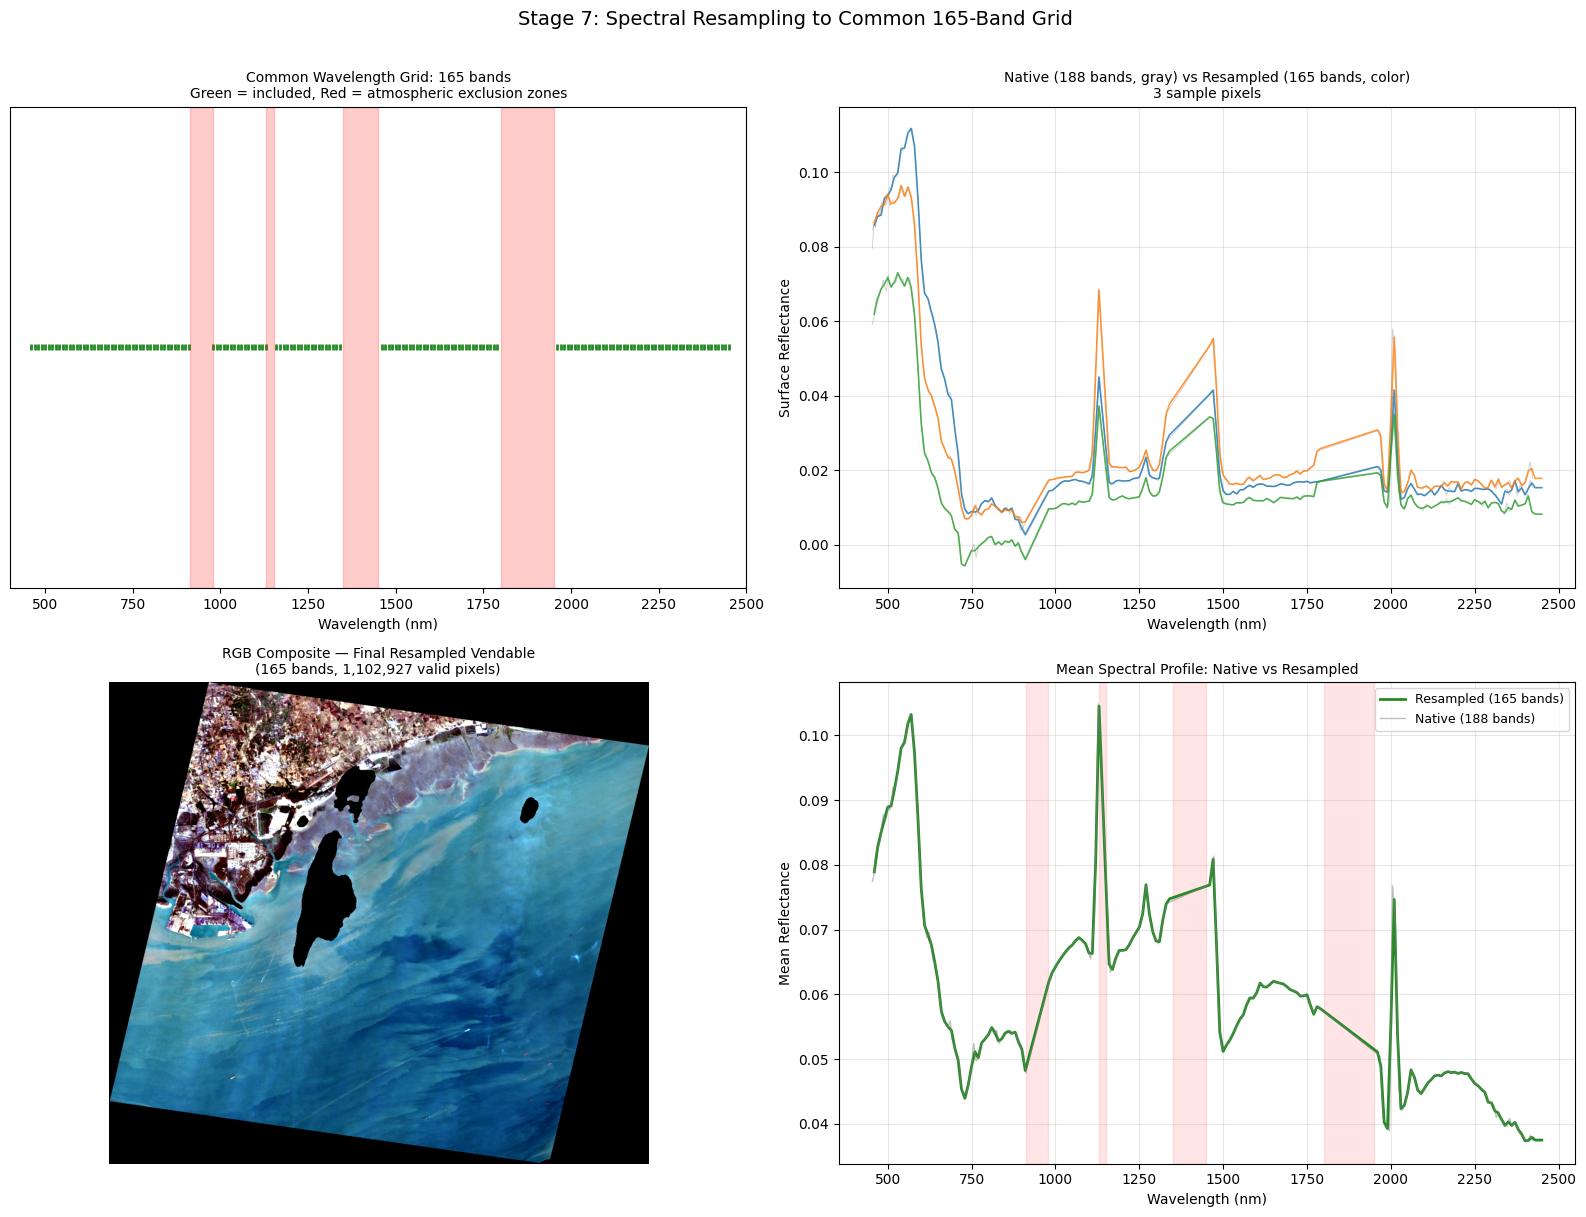

In [10]:
# Compare native vs resampled spectra
cube_r = ds_resampled.normalized_hyperspectral_cube
v_r = ds_resampled.validity_cube
wl_r = np.array(ds_resampled.band_cw_order)
C_r = cube_r.shape[0]

print(f"Resampled vendable:")
print(f"  Cube shape: {cube_r.shape}")
print(f"  Bands: {C_r}")
print(f"  Wavelength range: [{wl_r[0]:.0f}, {wl_r[-1]:.0f}] nm")
print(f"  Ascending: {np.all(np.diff(wl_r) > 0)}")
print(f"  Valid pixels: {int((v_r.sum(axis=0) > 0).sum()):,} / {v_r.shape[1]*v_r.shape[2]:,}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: Common grid visualization (which wavelengths are included)
axes[0, 0].scatter(wl_r, np.ones(C_r), c="forestgreen", s=15, marker="|", linewidths=2)
for lo, hi in cfg.exclusion_ranges:
    if lo > 400:
        axes[0, 0].axvspan(lo, hi, alpha=0.2, color="red")
axes[0, 0].set_xlabel("Wavelength (nm)")
axes[0, 0].set_yticks([])
axes[0, 0].set_title(f"Common Wavelength Grid: {C_r} bands\nGreen = included, Red = atmospheric exclusion zones", fontsize=10)
axes[0, 0].set_xlim([400, 2500])

# Top-right: Native vs resampled spectra for same pixel
spatial_v_r = (v_r.sum(axis=0) > 0).astype(np.uint8)
valid_px = np.argwhere(spatial_v_r == 1)
sample_px = valid_px[rng.choice(len(valid_px), 3, replace=False)]

native_wl_sorted = np.array(filt_wl)[sort_idx]
for px in sample_px:
    r, c = px
    native_spec = cube_f[sort_idx, r, c]
    resamp_spec = cube_r[:, r, c]
    axes[0, 1].plot(native_wl_sorted, native_spec, lw=0.6, alpha=0.4, color="gray")
    axes[0, 1].plot(wl_r, resamp_spec, lw=1.2, alpha=0.8)

axes[0, 1].set_xlabel("Wavelength (nm)")
axes[0, 1].set_ylabel("Surface Reflectance")
axes[0, 1].set_title(f"Native ({C_f} bands, gray) vs Resampled ({C_r} bands, color)\n3 sample pixels", fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: RGB composite from resampled cube
rgb_r = make_rgb_from_cube(cube_r, wl_r.tolist(), validity=spatial_v_r)
axes[1, 0].imshow(rgb_r)
axes[1, 0].set_title(f"RGB Composite — Final Resampled Vendable\n({C_r} bands, {int(spatial_v_r.sum()):,} valid pixels)", fontsize=10)
axes[1, 0].axis("off")

# Bottom-right: Mean spectral profile on common grid
mean_resamp = cube_r[:, spatial_v_r == 1].mean(axis=1)
axes[1, 1].plot(wl_r, mean_resamp, color="forestgreen", lw=2, label=f"Resampled ({C_r} bands)")

# Overlay native mean for comparison
mean_native = cube_f[sort_idx][:, (v.sum(axis=0) > 0)].mean(axis=1)
axes[1, 1].plot(native_wl_sorted, mean_native, color="gray", lw=1, alpha=0.5, label=f"Native ({C_f} bands)")

axes[1, 1].set_xlabel("Wavelength (nm)")
axes[1, 1].set_ylabel("Mean Reflectance")
axes[1, 1].set_title("Mean Spectral Profile: Native vs Resampled", fontsize=10)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)
for lo, hi in cfg.exclusion_ranges:
    if lo > 400:
        axes[1, 1].axvspan(lo, hi, alpha=0.1, color="red")

plt.suptitle("Stage 7: Spectral Resampling to Common 165-Band Grid", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Final Summary: Pipeline Progression

Let's summarize what happened at each stage with a single comparison view showing the data dimensions, validity, and spectral content through the entire pipeline.

                             ENMAP VENDABLE PIPELINE SUMMARY                              

Stage                                          Cube Shape  Bands    WL Range (nm) Valid Px %
------------------------------------------------------------------------------------------
Raw (no processing)                     (224, 1179, 1320)    224         418-2445      73.2%
Filtered (band+spatial+interp)          (188, 1179, 1320)    188         454-2423      70.9%
Resampled (common 165-band grid)        (165, 1179, 1320)    165         460-2450      70.9%


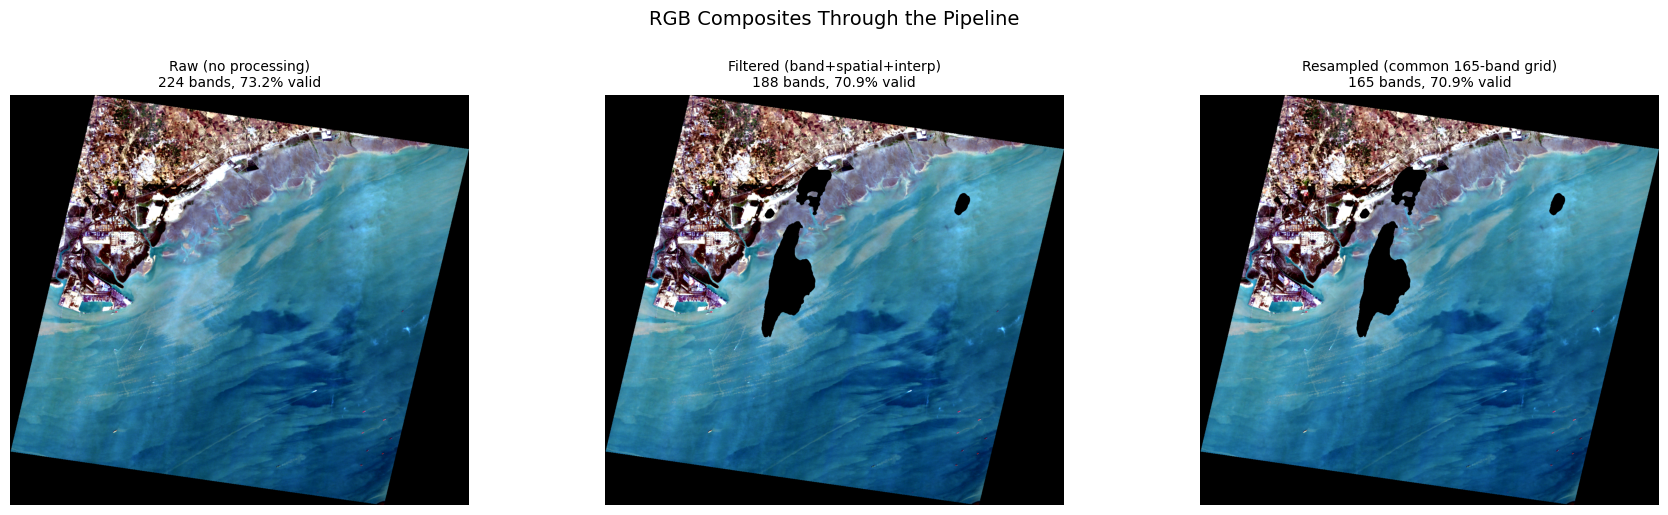

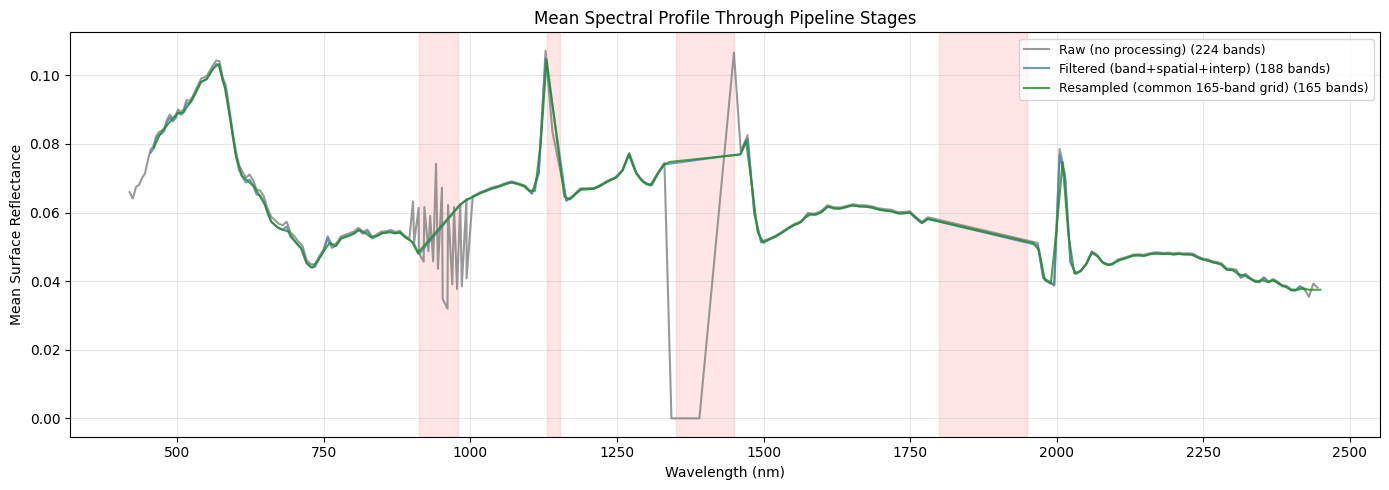


Pipeline complete. The final vendable is ready for patching and sharding.


In [11]:
# Summary table
print("=" * 90)
print(f"{'ENMAP VENDABLE PIPELINE SUMMARY':^90}")
print("=" * 90)

stages = [
    ("Raw (no processing)", ds_raw),
    ("Filtered (band+spatial+interp)", ds_filtered),
    ("Resampled (common 165-band grid)", ds_resampled),
]

print(f"\n{'Stage':<38} {'Cube Shape':>18} {'Bands':>6} {'WL Range (nm)':>16} {'Valid Px %':>10}")
print("-" * 90)

for label, ds in stages:
    cube = ds.normalized_hyperspectral_cube
    v = ds.validity_cube
    wl = ds.band_cw_order
    C, H, W = cube.shape
    valid_wl = [w for w in wl if w > 0]
    spatial_valid = (v.sum(axis=0) > 0).sum()
    valid_pct = spatial_valid / (H * W) * 100
    wl_range = f"{min(valid_wl):.0f}-{max(valid_wl):.0f}" if valid_wl else "N/A"
    print(f"{label:<38} {str(cube.shape):>18} {C:>6} {wl_range:>16} {valid_pct:>9.1f}%")

# Final comparison: RGB at each stage
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, ds) in enumerate(stages):
    cube = ds.normalized_hyperspectral_cube
    wl = ds.band_cw_order
    v = ds.validity_cube
    sv = (v.sum(axis=0) > 0).astype(np.uint8)
    rgb = make_rgb_from_cube(cube, wl, validity=sv)
    axes[idx].imshow(rgb)
    C = cube.shape[0]
    valid_pct = sv.sum() / sv.size * 100
    axes[idx].set_title(f"{label}\n{C} bands, {valid_pct:.1f}% valid", fontsize=10)
    axes[idx].axis("off")

plt.suptitle("RGB Composites Through the Pipeline", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Final spectral comparison
fig, ax = plt.subplots(figsize=(14, 5))

colors_stage = ["gray", "steelblue", "forestgreen"]
for (label, ds), color in zip(stages, colors_stage):
    cube = ds.normalized_hyperspectral_cube
    wl = np.array(ds.band_cw_order)
    v = ds.validity_cube
    sv = (v.sum(axis=0) > 0)
    sort = np.argsort(wl)
    mean_spec = cube[sort][:, sv].mean(axis=1)
    ax.plot(wl[sort], mean_spec, color=color, lw=1.5, alpha=0.8, label=f"{label} ({len(wl)} bands)")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Mean Surface Reflectance")
ax.set_title("Mean Spectral Profile Through Pipeline Stages", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
for lo, hi in cfg.exclusion_ranges:
    if lo > 400:
        ax.axvspan(lo, hi, alpha=0.1, color="red")
plt.tight_layout()
plt.show()

print("\nPipeline complete. The final vendable is ready for patching and sharding.")